# Credit Risk Analysis - Exploratory Data Analysis
## Week 1: Understanding the Data

### Objectives:
1. Load and inspect the dataset
2. Analyze target distribution (class imbalance)
3. Handle missing values
4. Feature distributions and correlations
5. Identify key risk indicators

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

**Dataset Options:**
- Give Me Some Credit (Kaggle): https://www.kaggle.com/c/GiveMeSomeCredit/data
- Lending Club: https://www.kaggle.com/datasets/wordsforthewise/lending-club
- Home Credit Default: https://www.kaggle.com/c/home-credit-default-risk/data

Download one and place in `../data/raw/` folder

In [2]:
# Load dataset
# Adjust the filename based on your dataset

# For Give Me Some Credit:
df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)

# For Lending Club:
# df = pd.read_csv('../data/raw/loan.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Records: {df.shape[0]:,}")
print(f"Features: {df.shape[1]}")

Dataset loaded successfully!
Shape: (150000, 11)
Records: 150,000
Features: 11


In [3]:
# First look at the data
df.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


In [4]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [5]:
# Statistical summary
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## 2. Target Variable Analysis (CRITICAL FOR CREDIT RISK)

Understanding class imbalance is crucial:
- Defaults are rare events (typically 5-10%)
- Models can achieve high accuracy by predicting "no default" always
- We need special handling (SMOTE, class weights)

Target Distribution:
No Default (0): 139,974 (93.32%)
Default (1): 10,026 (6.68%)

Imbalance Ratio: 1:14.0


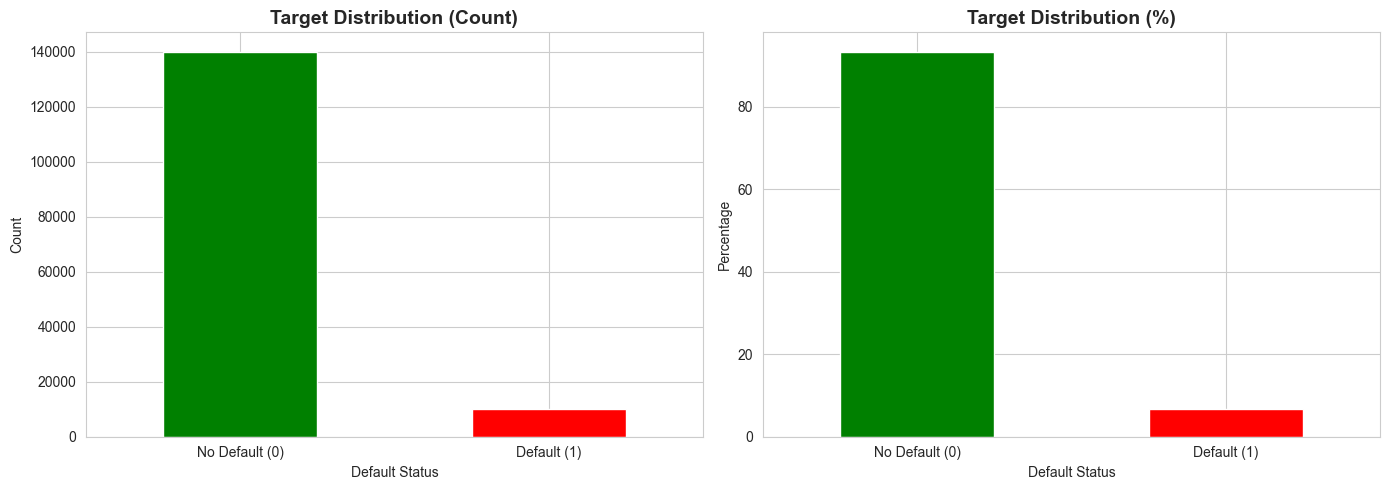

In [6]:
# Target variable (adjust column name based on your dataset)
# Common names: 'SeriousDlqin2yrs', 'loan_status', 'default'

target_col = 'SeriousDlqin2yrs'  # Change this based on your dataset

if target_col in df.columns:
    # Count and percentage
    target_counts = df[target_col].value_counts()
    target_pct = df[target_col].value_counts(normalize=True) * 100
    
    print("Target Distribution:")
    print(f"No Default (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
    print(f"Default (1): {target_counts[1]:,} ({target_pct[1]:.2f}%)")
    print(f"\nImbalance Ratio: 1:{target_counts[0]/target_counts[1]:.1f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Count plot
    target_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
    axes[0].set_title('Target Distribution (Count)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Default Status')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
    
    # Percentage plot
    target_pct.plot(kind='bar', ax=axes[1], color=['green', 'red'])
    axes[1].set_title('Target Distribution (%)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Default Status')
    axes[1].set_ylabel('Percentage')
    axes[1].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Bank reality check
    if target_pct[1] < 5:
        print("⚠️  SEVERE CLASS IMBALANCE (<5% defaults)")
        print("   → SMOTE/oversampling is MANDATORY")
        print("   → Use PR-AUC instead of accuracy")
else:
    print(f"Column '{target_col}' not found. Please update the target_col variable.")
    print(f"Available columns: {df.columns.tolist()}")

## 3. Missing Values Analysis

Missing Values Summary:
            Column  Missing_Count  Missing_Percentage
     MonthlyIncome          29731           19.820667
NumberOfDependents           3924            2.616000


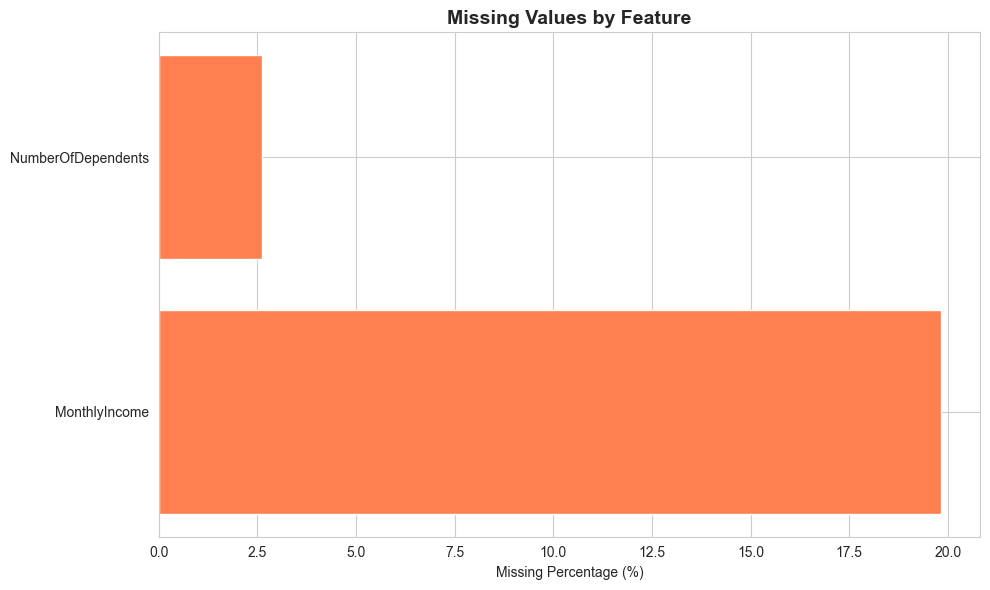

In [7]:
# Missing values
missing = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Percentage', ascending=False)

missing = missing[missing['Missing_Count'] > 0]

if len(missing) > 0:
    print("Missing Values Summary:")
    print(missing.to_string(index=False))
    
    # Visualize
    plt.figure(figsize=(10, 6))
    plt.barh(missing['Column'], missing['Missing_Percentage'], color='coral')
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Feature', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found!")

## 4. Feature Analysis

Key credit risk indicators:
- **Payment history**: Late payments, delinquencies
- **Credit utilization**: How much credit is being used
- **Debt burden**: Debt-to-income ratio
- **Credit age**: Length of credit history
- **Credit mix**: Types of credit accounts

In [8]:
# Separate numeric and categorical features
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from features
if target_col in numeric_features:
    numeric_features.remove(target_col)

print(f"Numeric Features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical Features ({len(categorical_features)}): {categorical_features}")

Numeric Features (10): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Categorical Features (0): []


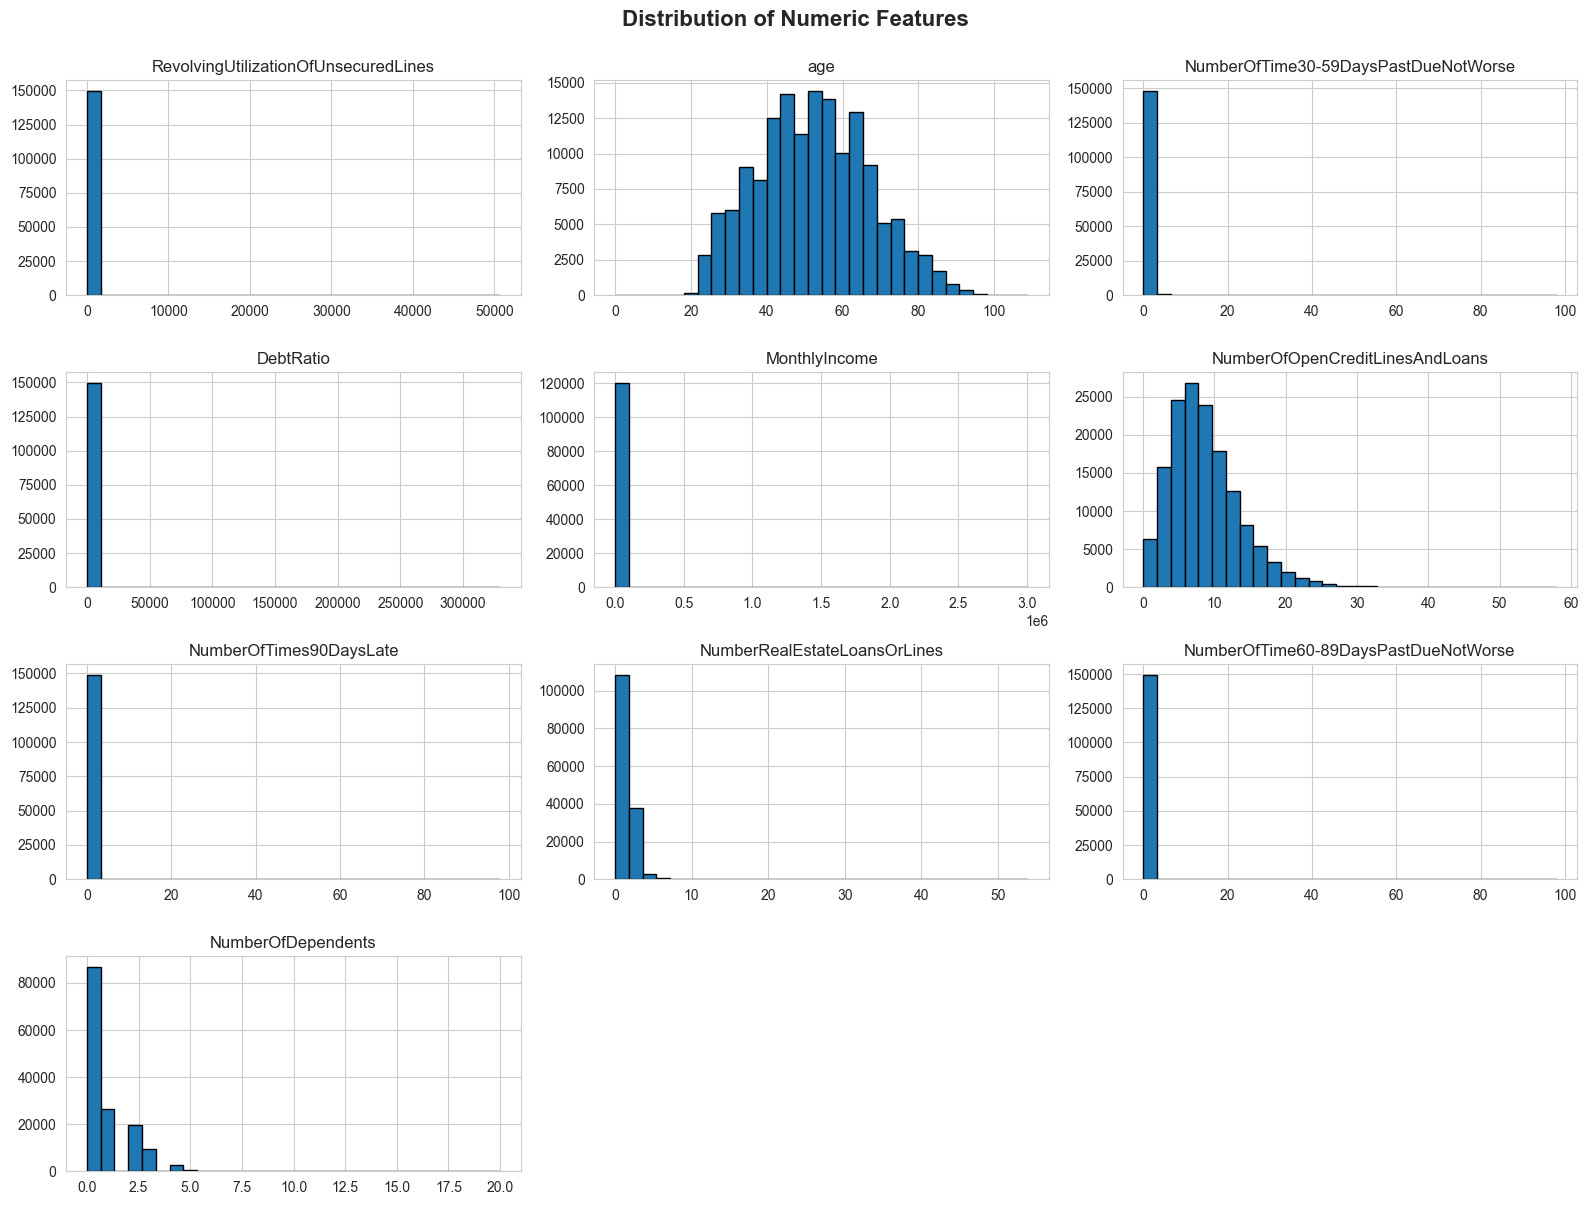

In [9]:
# Distribution of numeric features
if len(numeric_features) > 0:
    df[numeric_features].hist(bins=30, figsize=(16, 12), edgecolor='black')
    plt.suptitle('Distribution of Numeric Features', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

## 5. Correlation Analysis

Feature Correlations with Target:
SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64


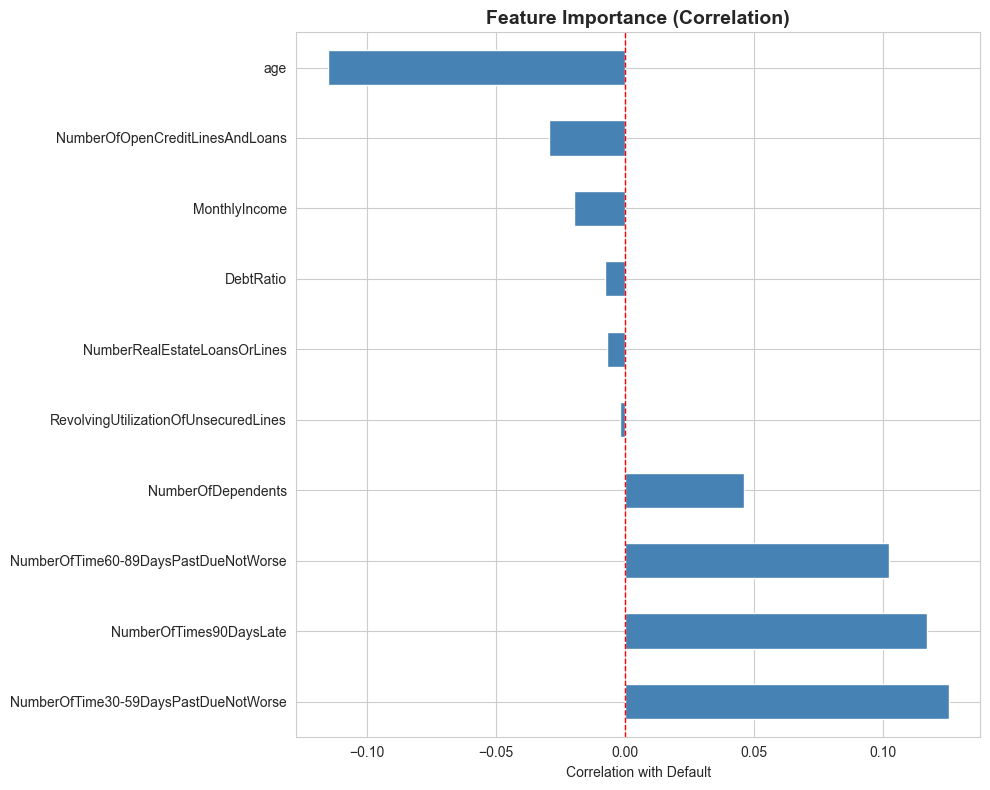

In [10]:
# Correlation matrix
if target_col in df.columns:
    # Calculate correlations
    correlations = df[numeric_features + [target_col]].corr()[target_col].sort_values(ascending=False)
    
    print("Feature Correlations with Target:")
    print(correlations)
    
    # Visualize
    plt.figure(figsize=(10, 8))
    correlations[1:].plot(kind='barh', color='steelblue')
    plt.xlabel('Correlation with Default')
    plt.title('Feature Importance (Correlation)', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()

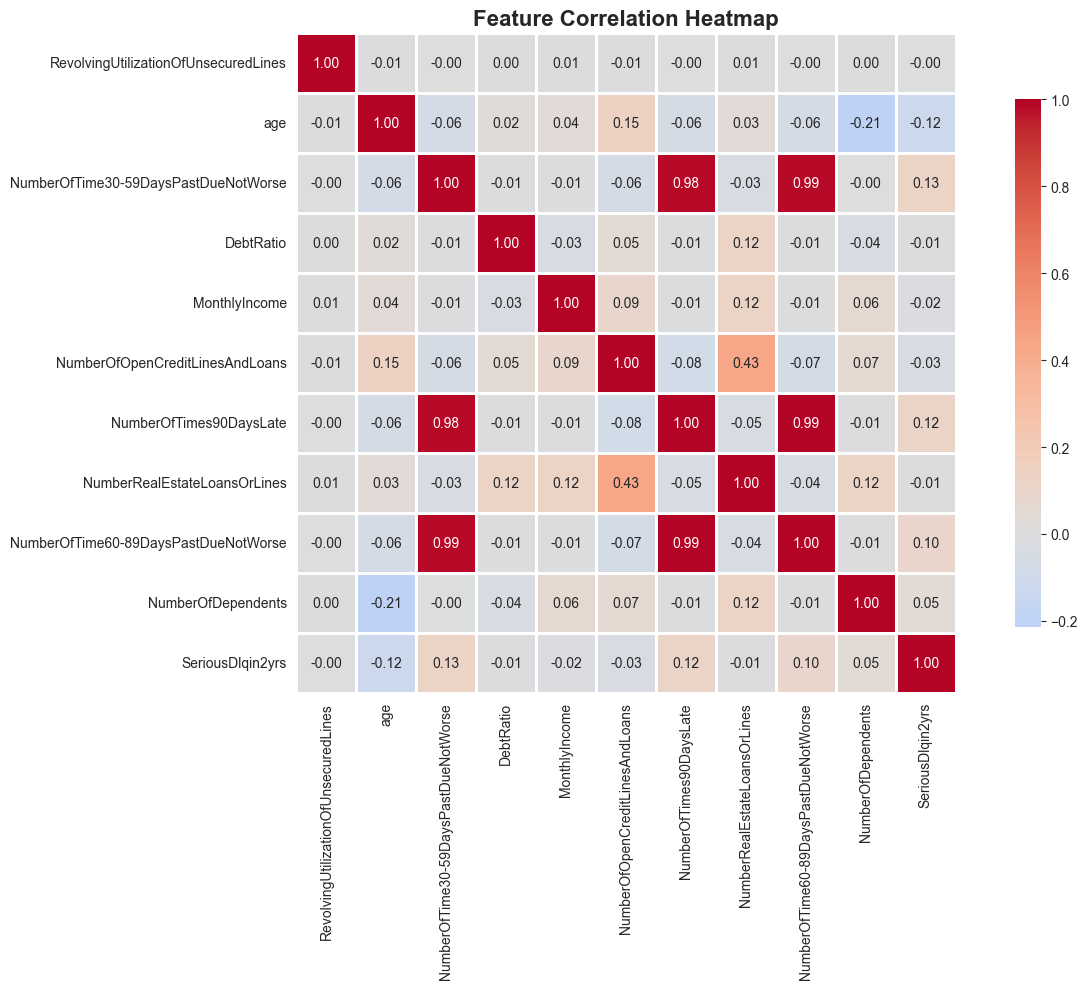

In [11]:
# Full correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df[numeric_features + [target_col]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature vs Target Analysis

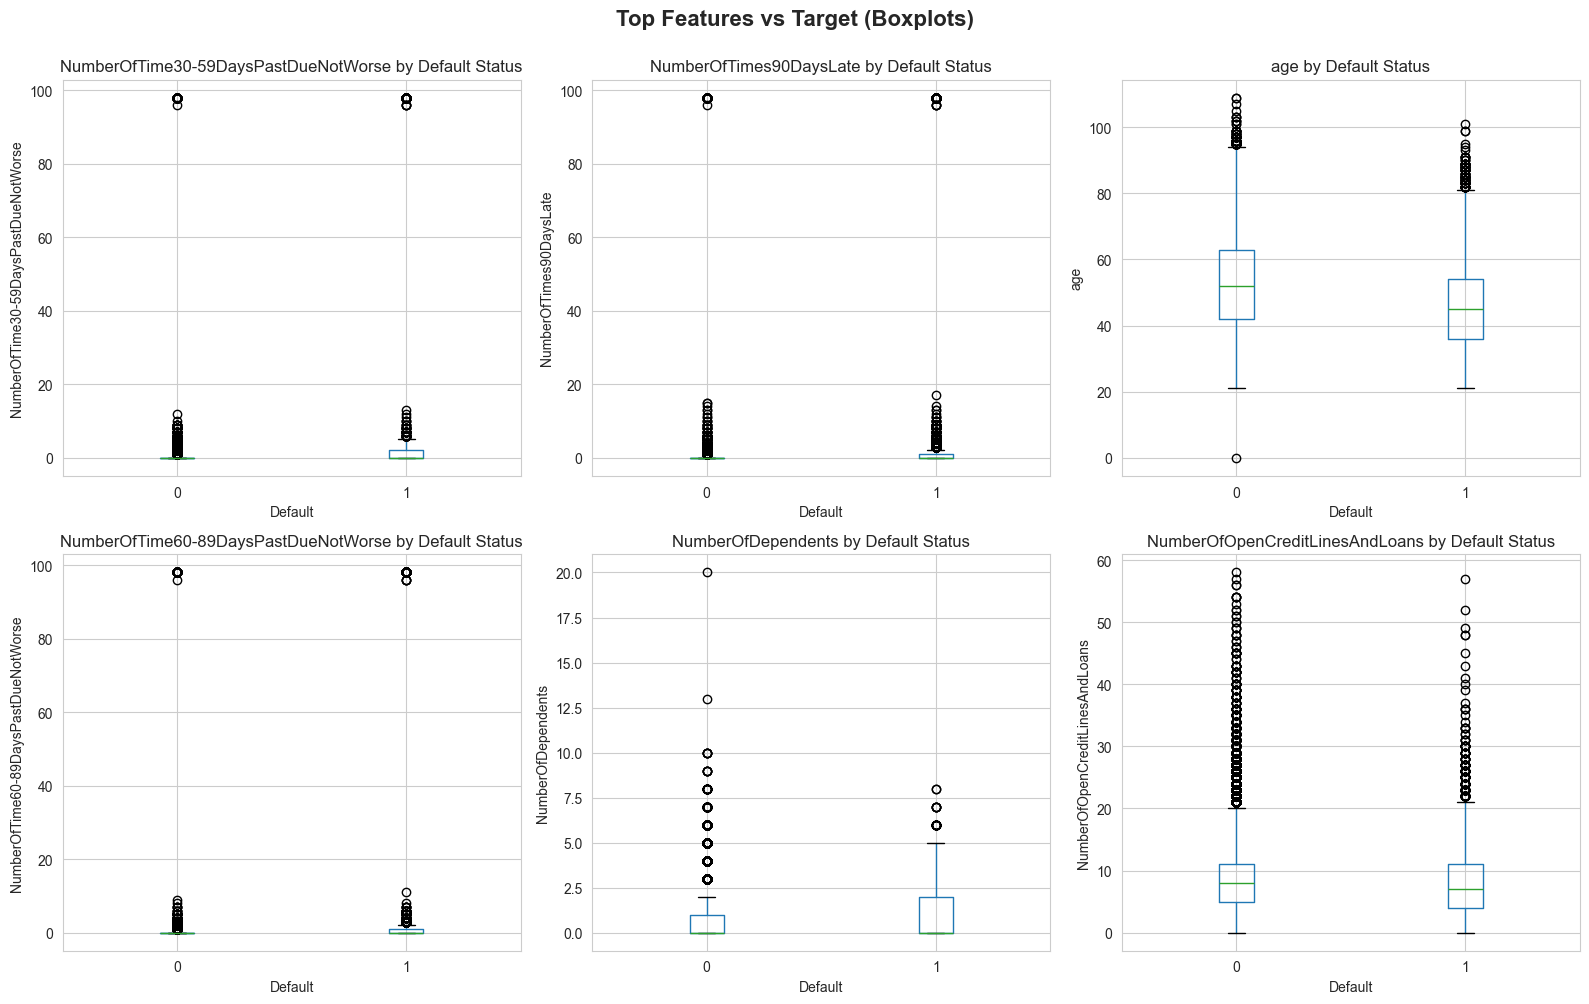

In [12]:
# Select top correlated features to visualize
if target_col in df.columns:
    top_features = correlations.abs().sort_values(ascending=False)[1:7].index.tolist()
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.ravel()
    
    for idx, feature in enumerate(top_features):
        if feature in df.columns:
            df.boxplot(column=feature, by=target_col, ax=axes[idx])
            axes[idx].set_title(f'{feature} by Default Status')
            axes[idx].set_xlabel('Default')
            axes[idx].set_ylabel(feature)
    
    plt.suptitle('Top Features vs Target (Boxplots)', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

## 7. Outlier Detection

In [13]:
# Outlier detection using IQR method
def detect_outliers(df, features):
    outlier_summary = []
    
    for feature in features:
        if feature in df.columns:
            Q1 = df[feature].quantile(0.25)
            Q3 = df[feature].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
            outlier_pct = (len(outliers) / len(df)) * 100
            
            outlier_summary.append({
                'Feature': feature,
                'Outlier_Count': len(outliers),
                'Outlier_Percentage': outlier_pct
            })
    
    return pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)

outlier_df = detect_outliers(df, numeric_features)
print("Outlier Summary:")
print(outlier_df.to_string(index=False))

Outlier Summary:
                             Feature  Outlier_Count  Outlier_Percentage
                           DebtRatio          31311           20.874000
NumberOfTime30-59DaysPastDueNotWorse          23982           15.988000
                  NumberOfDependents          13336            8.890667
             NumberOfTimes90DaysLate           8338            5.558667
NumberOfTime60-89DaysPastDueNotWorse           7604            5.069333
                       MonthlyIncome           4879            3.252667
     NumberOfOpenCreditLinesAndLoans           3980            2.653333
        NumberRealEstateLoansOrLines            793            0.528667
RevolvingUtilizationOfUnsecuredLines            763            0.508667
                                 age             46            0.030667


## 8. Key Insights & Next Steps

### Summary Checklist:
- [ ] Dataset loaded and explored
- [ ] Class imbalance identified (need SMOTE)
- [ ] Missing values analyzed
- [ ] Feature correlations calculated
- [ ] Outliers detected

### Next Notebook: `02_feature_engineering.ipynb`
- Handle missing values (domain-aware imputation)
- Create derived features:
  - Debt-to-income ratio
  - Credit utilization buckets
  - Delinquency score
- Encode categorical variables
- Train/test split (stratified)

In [14]:
# Save your insights here
print("\n" + "="*60)
print("EDA COMPLETE - KEY TAKEAWAYS:")
print("="*60)
print(f"1. Dataset Size: {df.shape[0]:,} records, {df.shape[1]} features")
if target_col in df.columns:
    print(f"2. Default Rate: {target_pct[1]:.2f}%")
    print(f"3. Imbalance Ratio: 1:{target_counts[0]/target_counts[1]:.1f}")
print(f"4. Missing Values: {len(missing)} features affected")
print(f"5. Top Risk Indicators: {top_features[:3]}")
print("\nReady for Feature Engineering!")


EDA COMPLETE - KEY TAKEAWAYS:
1. Dataset Size: 150,000 records, 11 features
2. Default Rate: 6.68%
3. Imbalance Ratio: 1:14.0
4. Missing Values: 2 features affected
5. Top Risk Indicators: ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'age']

Ready for Feature Engineering!
